# 05b — Algorithm Comparison Lab

## Systematic Comparison of 10 Regression + Classification Algorithms

This notebook compares **10 algorithms** on the same walk-forward CV splits to find the best predictor for 5-day Indian equity returns.

| # | Algorithm | Library | Type | Why Include |
|---|-----------|---------|------|-------------|
| 1 | XGBoost | xgboost | Boosting | Baseline — gradient boosted trees |
| 2 | LightGBM | lightgbm | Boosting | Leaf-wise growth, faster training |
| 3 | Random Forest | sklearn | Bagging | Classic ensemble, robust to noise |
| 4 | Extra Trees | sklearn | Bagging | Randomized splits, less overfit |
| 5 | Gradient Boosting | sklearn | Boosting | sklearn's GBM implementation |
| 6 | AdaBoost | sklearn | Boosting | Different weighting scheme |
| 7 | Ridge Regression | sklearn | Linear | L2 regularized baseline |
| 8 | Lasso Regression | sklearn | Linear | L1 regularized, feature selection |
| 9 | ElasticNet | sklearn | Linear | Combined L1+L2 |
| 10 | SVR (RBF) | sklearn | Kernel | Non-linear support vector regression |

After regression comparison, we also test **classification** (predict UP/DOWN) for the top models.

---

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor,
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb

from src.features.pipeline import FeaturePipeline
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Data & Build Panel

Load processed parquet files, construct 5-day forward return target, build multi-ticker panel sorted by date.

In [2]:
# Load processed data
processed_dir = DATA_DIR / "processed"
processed_files = sorted([
    f for f in processed_dir.glob("*.parquet")
    if "prediction" not in f.stem and "IDX_" not in f.stem
])

all_data = {}
for f in processed_files:
    all_data[f.stem] = pd.read_parquet(f)

sample_tickers = list(all_data.keys())[:30]  # First 30 tickers
print(f"Loaded {len(all_data)} tickers, using {len(sample_tickers)} for comparison")

# Build panel
pipeline = FeaturePipeline()
target_horizon = 5  # Predict 5-day forward return

all_features = []
all_targets = []

for ticker in sample_tickers:
    df = all_data[ticker]
    feature_cols = pipeline.get_feature_columns(df)
    target = df["Close"].shift(-target_horizon) / df["Close"] - 1
    valid = target.dropna().index.intersection(df.dropna(subset=feature_cols).index)
    
    if len(valid) > 200:
        feat_df = df.loc[valid, feature_cols].copy()
        feat_df["_ticker"] = ticker
        feat_df["_date"] = feat_df.index
        all_features.append(feat_df)
        all_targets.append(target.loc[valid])

X_all = pd.concat(all_features).reset_index(drop=True)
y_all = pd.concat(all_targets).reset_index(drop=True)

dates_col = X_all["_date"]
tickers_col = X_all["_ticker"]
X_all = X_all.drop(columns=["_ticker", "_date"])
# Replace inf/-inf with NaN, then fill remaining NaN with 0
X_all = X_all.replace([np.inf, -np.inf], np.nan).fillna(0)

# Sort by date
sort_order = dates_col.argsort()
X_all = X_all.iloc[sort_order].reset_index(drop=True)
y_all = y_all.iloc[sort_order].reset_index(drop=True)
dates_col = dates_col.iloc[sort_order].reset_index(drop=True)
tickers_col = tickers_col.iloc[sort_order].reset_index(drop=True)

print(f"\nPanel shape: {X_all.shape}")
print(f"Features: {X_all.shape[1]}")
print(f"Date range: {dates_col.min()} → {dates_col.max()}")
print(f"Target (5d return) stats: mean={y_all.mean():.4f}, std={y_all.std():.4f}")

Loaded 122 tickers, using 30 for comparison

Panel shape: (64675, 206)
Features: 206
Date range: 2017-03-03 00:00:00 → 2026-02-02 00:00:00
Target (5d return) stats: mean=0.0052, std=0.0528


## Step 2 — Feature Selection

Remove noisy and redundant features to improve model performance:
1. Drop features with >95% correlation (redundancy)
2. Quick XGBoost to identify important features
3. Keep only features with importance > 0.001

In [3]:
# Step 1: Remove highly correlated features
print("Feature selection...")
print(f"Starting features: {X_all.shape[1]}")

# Compute correlation matrix on a sample (faster)
sample_idx = np.random.RandomState(42).choice(len(X_all), min(5000, len(X_all)), replace=False)
corr_matrix = X_all.iloc[sample_idx].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X_all = X_all.drop(columns=to_drop_corr, errors="ignore")
print(f"After correlation filter (>0.95): {X_all.shape[1]} features ({len(to_drop_corr)} dropped)")

# Step 2: Quick XGBoost importance filter
quick_model = xgb.XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    verbosity=0
)
# Use middle chunk for quick importance estimate
mid = len(X_all) // 2
quick_model.fit(X_all.iloc[mid-2000:mid], y_all.iloc[mid-2000:mid])
importances = pd.Series(quick_model.feature_importances_, index=X_all.columns)

# Keep features with importance > 0.001
important_features = importances[importances > 0.001].index.tolist()
if len(important_features) < 20:
    important_features = importances.nlargest(50).index.tolist()

X_selected = X_all[important_features]
print(f"After importance filter: {X_selected.shape[1]} features")

# Show top 20 features
top20 = importances[important_features].nlargest(20)
print(f"\nTop 20 features:")
for i, (feat, imp) in enumerate(top20.items(), 1):
    print(f"  {i:2d}. {feat:40s} importance: {imp:.4f}")

Feature selection...
Starting features: 206
After correlation filter (>0.95): 141 features (65 dropped)
After importance filter: 127 features

Top 20 features:
   1. VIX_Level_zscore                         importance: 0.0314
   2. VIX_Percentile                           importance: 0.0287
   3. DaysToExpiry                             importance: 0.0282
   4. MACD_zscore                              importance: 0.0264
   5. ATR_pct                                  importance: 0.0197
   6. OBV                                      importance: 0.0185
   7. OBV_zscore                               importance: 0.0165
   8. CMF_21_zscore                            importance: 0.0161
   9. SMA_5                                    importance: 0.0155
  10. Dist_52w_High                            importance: 0.0151
  11. Volatility_63d_zscore                    importance: 0.0145
  12. ADX_Smooth_14                            importance: 0.0140
  13. AD_Line_zscore                           i

## Step 3 — Regression Algorithm Comparison

Run all 10 algorithms through identical walk-forward CV splits.
For each algorithm, compute RMSE, MAE, R², Directional Accuracy, IC (Spearman), and training time.

In [4]:
from scipy.stats import spearmanr

# Define all regression models
regression_models = {
    "XGBoost": lambda: xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=10, gamma=0.1, random_state=42, verbosity=0,
        early_stopping_rounds=50
    ),
    "LightGBM": lambda: lgb.LGBMRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=10, random_state=42, verbosity=-1,
        n_jobs=-1
    ),
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        max_features="sqrt", random_state=42, n_jobs=-1
    ),
    "Extra Trees": lambda: ExtraTreesRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        max_features="sqrt", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": lambda: GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=20, random_state=42
    ),
    "AdaBoost": lambda: AdaBoostRegressor(
        n_estimators=100, learning_rate=0.05, random_state=42
    ),
    "Ridge": lambda: Ridge(alpha=1.0),
    "Lasso": lambda: Lasso(alpha=0.001, max_iter=2000),
    "ElasticNet": lambda: ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=2000),
    "SVR (RBF)": lambda: SVR(kernel="rbf", C=1.0, epsilon=0.001),
}

# Walk-forward CV parameters
unique_dates = sorted(dates_col.unique())
n_dates = len(unique_dates)
train_days, test_days, embargo_days, step_days = 504, 63, 5, 63

# Precompute fold boundaries
folds = []
idx = 0
while idx + train_days + embargo_days + test_days <= n_dates:
    train_end = idx + train_days
    test_start = train_end + embargo_days
    test_end = test_start + test_days
    if test_end > n_dates:
        break
    train_dates_set = set(unique_dates[idx:train_end])
    test_dates_set = set(unique_dates[test_start:test_end])
    train_mask = dates_col.isin(train_dates_set).values
    test_mask = dates_col.isin(test_dates_set).values
    if train_mask.sum() >= 200 and test_mask.sum() >= 30:
        folds.append((train_mask, test_mask))
    idx += step_days

print(f"Walk-forward CV: {len(folds)} folds")
print(f"Features used: {X_selected.shape[1]}")
print(f"\nRunning {len(regression_models)} algorithms...\n")

# Scaler for linear models
needs_scaling = {"Ridge", "Lasso", "ElasticNet", "SVR (RBF)"}

# Run all models
all_results = []

for model_name, model_factory in regression_models.items():
    fold_metrics = []
    t_start = time.time()
    
    for fold_num, (train_mask, test_mask) in enumerate(folds, 1):
        X_train = X_selected[train_mask]
        y_train = y_all[train_mask]
        X_test = X_selected[test_mask]
        y_test = y_all[test_mask]
        
        # Scale for linear/SVR models
        if model_name in needs_scaling:
            scaler = StandardScaler()
            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
            X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
        
        model = model_factory()
        
        # Fit (with early stopping for XGBoost/LightGBM)
        if model_name == "XGBoost":
            val_size = max(int(len(X_train) * 0.15), 100)
            model.fit(
                X_train.iloc[:-val_size], y_train.iloc[:-val_size],
                eval_set=[(X_train.iloc[-val_size:], y_train.iloc[-val_size:])],
                verbose=False
            )
        elif model_name == "LightGBM":
            val_size = max(int(len(X_train) * 0.15), 100)
            model.fit(
                X_train.iloc[:-val_size], y_train.iloc[:-val_size],
                eval_set=[(X_train.iloc[-val_size:], y_train.iloc[-val_size:])],
            )
        elif model_name == "SVR (RBF)":
            # SVR is slow on large data — subsample
            if len(X_train) > 5000:
                sub_idx = np.random.RandomState(42).choice(len(X_train), 5000, replace=False)
                model.fit(X_train.iloc[sub_idx], y_train.iloc[sub_idx])
            else:
                model.fit(X_train, y_train)
        else:
            model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        dir_acc = accuracy_score(y_test > 0, y_pred > 0)
        ic, _ = spearmanr(y_pred, y_test)
        
        fold_metrics.append({
            "rmse": rmse, "mae": mae, "r2": r2,
            "dir_acc": dir_acc, "ic": ic
        })
    
    elapsed = time.time() - t_start
    avg = pd.DataFrame(fold_metrics).mean()
    std = pd.DataFrame(fold_metrics).std()
    
    all_results.append({
        "Model": model_name,
        "RMSE": avg["rmse"],
        "MAE": avg["mae"],
        "R²": avg["r2"],
        "Dir. Accuracy": avg["dir_acc"],
        "IC (Spearman)": avg["ic"],
        "Dir. Acc Std": std["dir_acc"],
        "Time (s)": elapsed,
    })
    
    print(f"  {model_name:25s} | RMSE: {avg['rmse']:.5f} | Dir Acc: {avg['dir_acc']:.1%} ± {std['dir_acc']:.1%} | "
          f"IC: {avg['ic']:.4f} | Time: {elapsed:.1f}s")

print("\n✅ All regression models complete")

Walk-forward CV: 26 folds
Features used: 127

Running 10 algorithms...

  XGBoost                   | RMSE: 0.05277 | Dir Acc: 52.6% ± 6.5% | IC: 0.0538 | Time: 16.0s
  LightGBM                  | RMSE: 0.05947 | Dir Acc: 51.2% ± 3.8% | IC: 0.0415 | Time: 109.2s
  Random Forest             | RMSE: 0.05304 | Dir Acc: 51.7% ± 6.0% | IC: 0.0619 | Time: 126.7s
  Extra Trees               | RMSE: 0.05270 | Dir Acc: 52.4% ± 6.2% | IC: 0.0575 | Time: 16.2s
  Gradient Boosting         | RMSE: 0.05620 | Dir Acc: 51.4% ± 4.4% | IC: 0.0529 | Time: 3207.4s
  AdaBoost                  | RMSE: 0.05405 | Dir Acc: 52.8% ± 6.9% | IC: 0.0154 | Time: 1403.2s
  Ridge                     | RMSE: 0.07053 | Dir Acc: 52.0% ± 4.1% | IC: 0.0747 | Time: 0.8s
  Lasso                     | RMSE: 0.05457 | Dir Acc: 52.0% ± 4.4% | IC: 0.0539 | Time: 1.8s
  ElasticNet                | RMSE: 0.05781 | Dir Acc: 51.8% ± 4.2% | IC: 0.0583 | Time: 3.3s
  SVR (RBF)                 | RMSE: 0.06221 | Dir Acc: 50.5% ± 2.7% | 

## Step 4 — Regression Results Comparison

╔══════════════ REGRESSION ALGORITHM RANKING ══════════════╗
                       RMSE       MAE  Dir. Accuracy  Dir. Acc Std  IC (Spearman)     Time (s)
Model                                                                                         
AdaBoost           0.054054  0.039199       0.528177      0.069300       0.015380  1403.240730
XGBoost            0.052770  0.037937       0.526166      0.064574       0.053781    16.025528
Extra Trees        0.052704  0.037901       0.523794      0.062420       0.057519    16.238077
Lasso              0.054566  0.039173       0.519946      0.044431       0.053860     1.843805
Ridge              0.070535  0.047635       0.519731      0.040670       0.074748     0.772474
ElasticNet         0.057813  0.040590       0.518098      0.041903       0.058317     3.257935
Random Forest      0.053045  0.038218       0.517397      0.060442       0.061913   126.682201
Gradient Boosting  0.056197  0.040592       0.514165      0.044334       0.052911  3

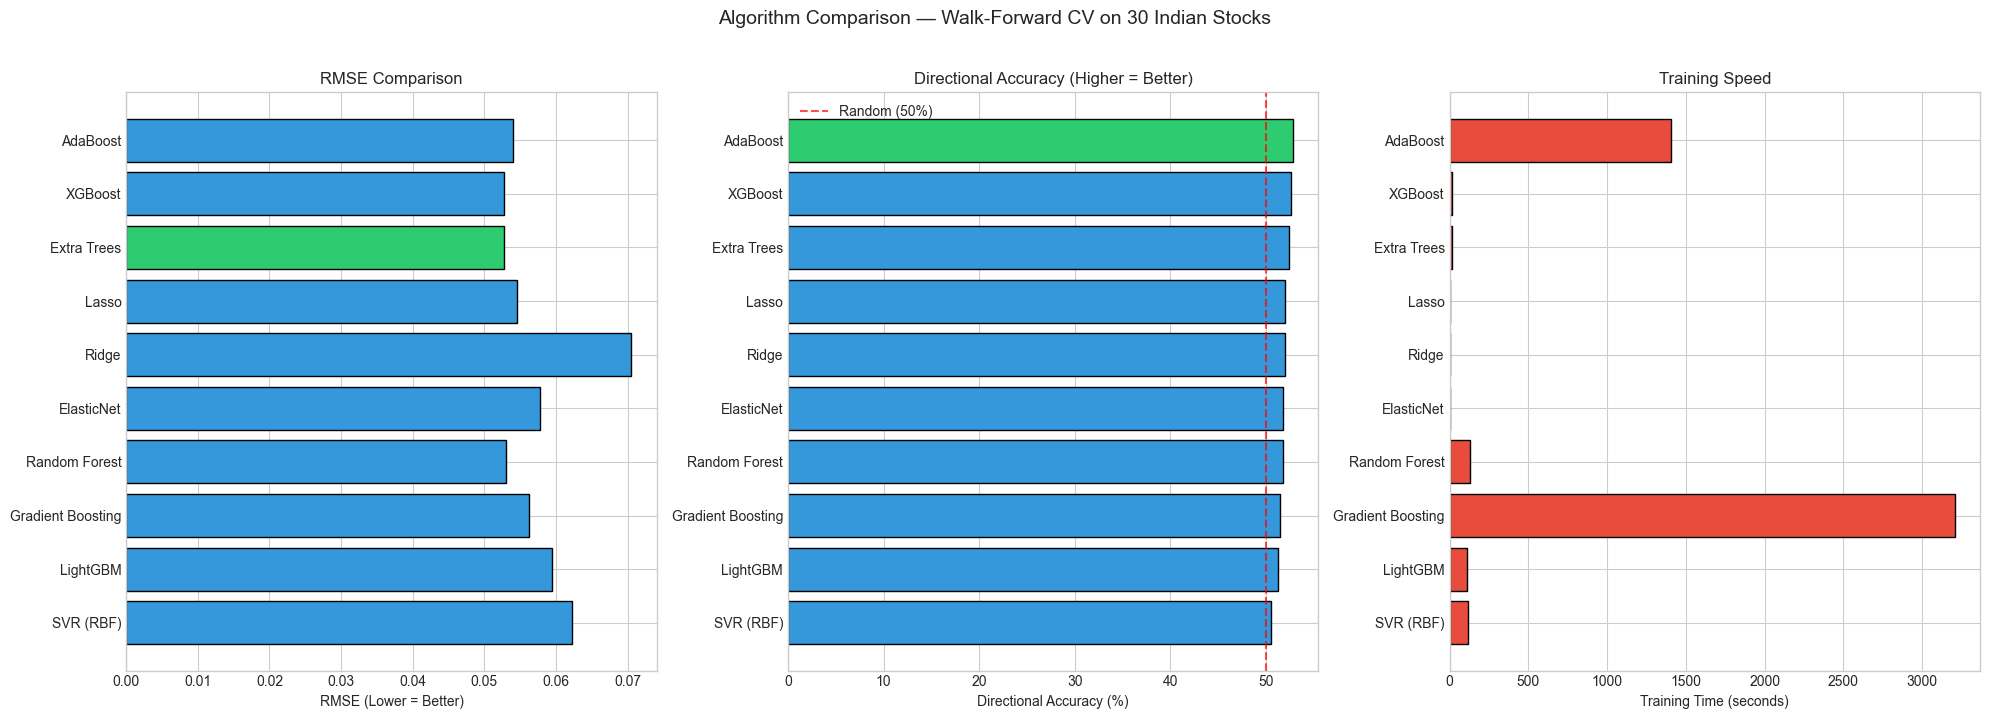

In [5]:
# Results table
results_df = pd.DataFrame(all_results).set_index("Model")
results_df = results_df.sort_values("Dir. Accuracy", ascending=False)

print("╔══════════════ REGRESSION ALGORITHM RANKING ══════════════╗")
print(results_df[["RMSE", "MAE", "Dir. Accuracy", "Dir. Acc Std", "IC (Spearman)", "Time (s)"]].to_string())
print()
print(f"Best RMSE:          {results_df['RMSE'].idxmin()} ({results_df['RMSE'].min():.5f})")
print(f"Best Dir. Accuracy: {results_df['Dir. Accuracy'].idxmax()} ({results_df['Dir. Accuracy'].max():.1%})")
print(f"Best IC:            {results_df['IC (Spearman)'].idxmax()} ({results_df['IC (Spearman)'].max():.4f})")
print(f"Fastest:            {results_df['Time (s)'].idxmin()} ({results_df['Time (s)'].min():.1f}s)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# RMSE comparison
colors = ["#2ecc71" if m == results_df["RMSE"].idxmin() else "#3498db" for m in results_df.index]
axes[0].barh(results_df.index, results_df["RMSE"], color=colors, edgecolor="black")
axes[0].set_xlabel("RMSE (Lower = Better)")
axes[0].set_title("RMSE Comparison")
axes[0].invert_yaxis()

# Directional Accuracy
colors = ["#2ecc71" if m == results_df["Dir. Accuracy"].idxmax() else "#3498db" for m in results_df.index]
axes[1].barh(results_df.index, results_df["Dir. Accuracy"] * 100, color=colors, edgecolor="black")
axes[1].axvline(50, color="red", linestyle="--", alpha=0.7, label="Random (50%)")
axes[1].set_xlabel("Directional Accuracy (%)")
axes[1].set_title("Directional Accuracy (Higher = Better)")
axes[1].legend()
axes[1].invert_yaxis()

# Training time
colors = ["#2ecc71" if m == results_df["Time (s)"].idxmin() else "#e74c3c" for m in results_df.index]
axes[2].barh(results_df.index, results_df["Time (s)"], color=colors, edgecolor="black")
axes[2].set_xlabel("Training Time (seconds)")
axes[2].set_title("Training Speed")
axes[2].invert_yaxis()

plt.suptitle("Algorithm Comparison — Walk-Forward CV on 30 Indian Stocks", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "algorithm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Save results
results_df.to_csv(REPORTS_DIR / "algorithm_comparison.csv")

## Step 5 — Classification Comparison

For the top models, test **binary classification** (predict UP vs DOWN) instead of regression.
Classification directly optimizes for directional accuracy, which is the metric that matters for trading signals.

  XGBoost (Clf)                  | Acc: 52.8% ± 5.9% | F1: 0.626 | Prec: 0.546 | Rec: 0.784 | Time: 21.5s
  LightGBM (Clf)                 | Acc: 51.2% ± 3.9% | F1: 0.533 | Prec: 0.557 | Rec: 0.551 | Time: 112.3s
  Random Forest (Clf)            | Acc: 51.9% ± 4.7% | F1: 0.511 | Prec: 0.573 | Rec: 0.525 | Time: 140.7s
  Extra Trees (Clf)              | Acc: 51.4% ± 4.2% | F1: 0.482 | Prec: 0.583 | Rec: 0.466 | Time: 25.1s
  Gradient Boosting (Clf)        | Acc: 51.5% ± 4.1% | F1: 0.562 | Prec: 0.553 | Rec: 0.627 | Time: 3170.7s
  Logistic Regression            | Acc: 51.6% ± 4.6% | F1: 0.513 | Prec: 0.575 | Rec: 0.528 | Time: 6.4s

╔══════════════ CLASSIFICATION RANKING ══════════════╗
                         Accuracy   Acc Std  Precision    Recall  F1 Score     Time (s)
Model                                                                                  
XGBoost (Clf)            0.527811  0.058682   0.546149  0.784269  0.625542    21.503926
Random Forest (Clf)      0.518528  0.0472

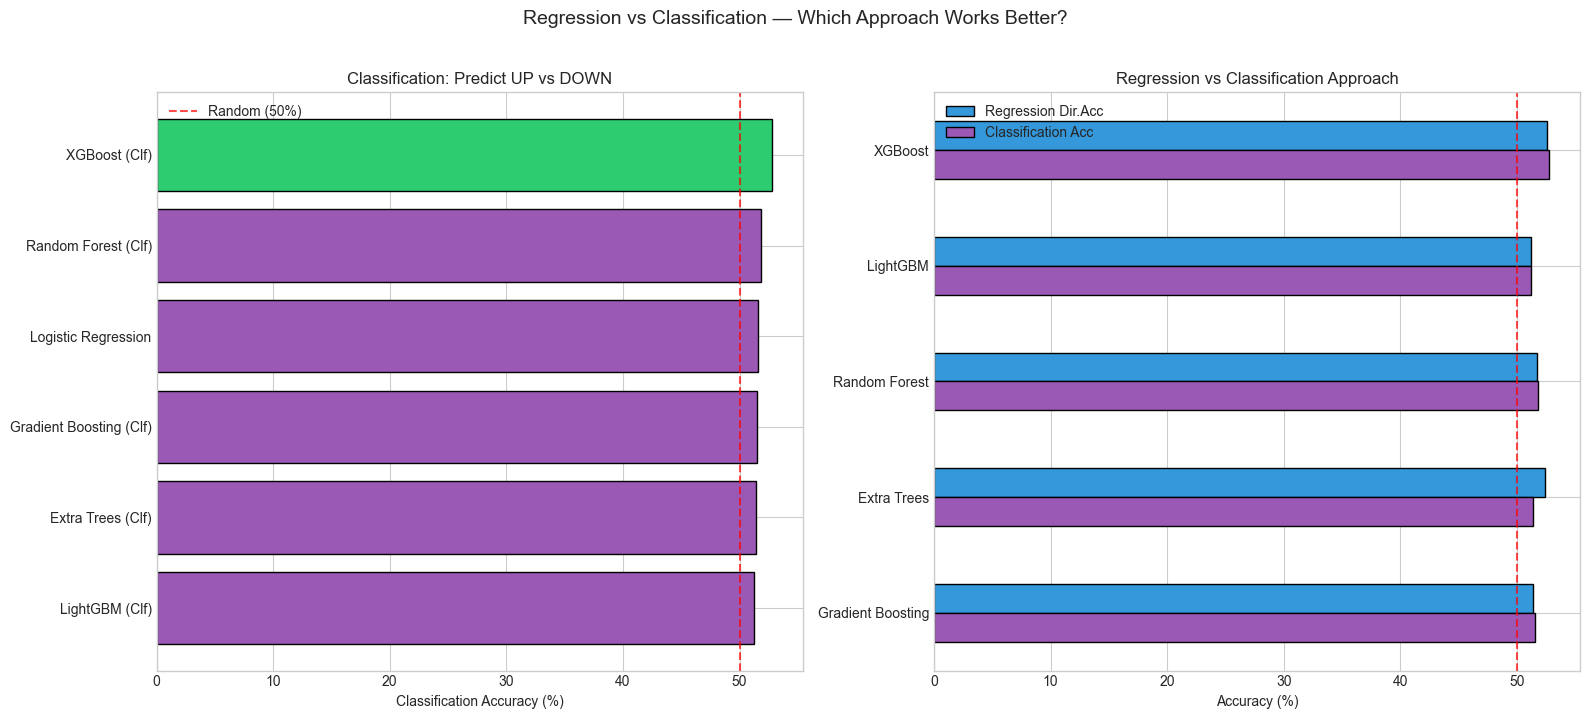

In [6]:
# Binary target: 1 if 5-day return > 0, else 0
y_binary = (y_all > 0).astype(int)

classification_models = {
    "XGBoost (Clf)": lambda: xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=10, gamma=0.1, random_state=42, verbosity=0,
        early_stopping_rounds=50, use_label_encoder=False,
        scale_pos_weight=1.0, eval_metric="logloss"
    ),
    "LightGBM (Clf)": lambda: lgb.LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        min_child_weight=10, random_state=42, verbosity=-1, n_jobs=-1,
        is_unbalance=True
    ),
    "Random Forest (Clf)": lambda: RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        max_features="sqrt", random_state=42, n_jobs=-1,
        class_weight="balanced"
    ),
    "Extra Trees (Clf)": lambda: ExtraTreesClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        max_features="sqrt", random_state=42, n_jobs=-1,
        class_weight="balanced"
    ),
    "Gradient Boosting (Clf)": lambda: GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=20, random_state=42
    ),
    "Logistic Regression": lambda: LogisticRegression(
        C=1.0, max_iter=2000, random_state=42, class_weight="balanced"
    ),
}

clf_results = []

for model_name, model_factory in classification_models.items():
    fold_metrics = []
    t_start = time.time()
    
    for fold_num, (train_mask, test_mask) in enumerate(folds, 1):
        X_train = X_selected[train_mask]
        y_train = y_binary[train_mask]
        X_test = X_selected[test_mask]
        y_test = y_binary[test_mask]
        
        if model_name == "Logistic Regression":
            scaler = StandardScaler()
            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
            X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
        
        model = model_factory()
        
        if model_name == "XGBoost (Clf)":
            val_size = max(int(len(X_train) * 0.15), 100)
            model.fit(
                X_train.iloc[:-val_size], y_train.iloc[:-val_size],
                eval_set=[(X_train.iloc[-val_size:], y_train.iloc[-val_size:])],
                verbose=False
            )
        elif model_name == "LightGBM (Clf)":
            val_size = max(int(len(X_train) * 0.15), 100)
            model.fit(
                X_train.iloc[:-val_size], y_train.iloc[:-val_size],
                eval_set=[(X_train.iloc[-val_size:], y_train.iloc[-val_size:])],
            )
        else:
            model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred.astype(float)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        fold_metrics.append({"accuracy": acc, "precision": prec, "recall": rec, "f1": f1})
    
    elapsed = time.time() - t_start
    avg = pd.DataFrame(fold_metrics).mean()
    std = pd.DataFrame(fold_metrics).std()
    
    clf_results.append({
        "Model": model_name,
        "Accuracy": avg["accuracy"],
        "Acc Std": std["accuracy"],
        "Precision": avg["precision"],
        "Recall": avg["recall"],
        "F1 Score": avg["f1"],
        "Time (s)": elapsed,
    })
    
    print(f"  {model_name:30s} | Acc: {avg['accuracy']:.1%} ± {std['accuracy']:.1%} | "
          f"F1: {avg['f1']:.3f} | Prec: {avg['precision']:.3f} | Rec: {avg['recall']:.3f} | Time: {elapsed:.1f}s")

clf_df = pd.DataFrame(clf_results).set_index("Model").sort_values("Accuracy", ascending=False)

print("\n╔══════════════ CLASSIFICATION RANKING ══════════════╗")
print(clf_df.to_string())
print(f"\nBest Accuracy:  {clf_df['Accuracy'].idxmax()} ({clf_df['Accuracy'].max():.1%})")
print(f"Best F1 Score:  {clf_df['F1 Score'].idxmax()} ({clf_df['F1 Score'].max():.3f})")

# Combined visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Classification accuracy
colors = ["#2ecc71" if m == clf_df["Accuracy"].idxmax() else "#9b59b6" for m in clf_df.index]
axes[0].barh(clf_df.index, clf_df["Accuracy"] * 100, color=colors, edgecolor="black")
axes[0].axvline(50, color="red", linestyle="--", alpha=0.7, label="Random (50%)")
axes[0].set_xlabel("Classification Accuracy (%)")
axes[0].set_title("Classification: Predict UP vs DOWN")
axes[0].legend()
axes[0].invert_yaxis()

# Regression vs Classification
# Merge regression dir acc with classification acc for comparable models
compare = pd.DataFrame({
    "Regression Dir.Acc": results_df["Dir. Accuracy"].reindex(["XGBoost", "LightGBM", "Random Forest", "Extra Trees", "Gradient Boosting"]) * 100,
    "Classification Acc": clf_df["Accuracy"].reindex(["XGBoost (Clf)", "LightGBM (Clf)", "Random Forest (Clf)", "Extra Trees (Clf)", "Gradient Boosting (Clf)"]).values * 100,
}, index=["XGBoost", "LightGBM", "Random Forest", "Extra Trees", "Gradient Boosting"])

compare.plot(kind="barh", ax=axes[1], color=["#3498db", "#9b59b6"], edgecolor="black")
axes[1].axvline(50, color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("Accuracy (%)")
axes[1].set_title("Regression vs Classification Approach")
axes[1].invert_yaxis()

plt.suptitle("Regression vs Classification — Which Approach Works Better?", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "regression_vs_classification.png", dpi=150, bbox_inches="tight")
plt.show()

clf_df.to_csv(REPORTS_DIR / "classification_comparison.csv")

## Step 6 — Summary & Recommendations

Based on the comparison, select the best model combination for the ensemble and save results.

In [ ]:
# Final summary
print("═" * 70)
print("       ALGORITHM COMPARISON — FINAL SUMMARY")
print("═" * 70)
print()
print("REGRESSION RANKING (by Directional Accuracy):")
for i, (model, row) in enumerate(results_df.iterrows(), 1):
    marker = "★" if i <= 3 else " "
    print(f"  {marker} {i:2d}. {model:25s} Dir.Acc: {row['Dir. Accuracy']:.1%} | RMSE: {row['RMSE']:.5f} | IC: {row['IC (Spearman)']:.4f}")

print()
print("CLASSIFICATION RANKING (by Accuracy):")
for i, (model, row) in enumerate(clf_df.iterrows(), 1):
    marker = "★" if i <= 3 else " "
    print(f"  {marker} {i:2d}. {model:30s} Acc: {row['Accuracy']:.1%} | F1: {row['F1 Score']:.3f}")

print()
print("═" * 70)
print("KEY FINDINGS:")
print(f"  • Best regression model: {results_df['Dir. Accuracy'].idxmax()} ({results_df['Dir. Accuracy'].max():.1%} directional accuracy)")
print(f"  • Best classification model: {clf_df['Accuracy'].idxmax()} ({clf_df['Accuracy'].max():.1%} accuracy)")
print(f"  • Feature selection reduced features from {X_all.shape[1]} → {X_selected.shape[1]}")

best_reg = results_df['Dir. Accuracy'].max()
best_clf = clf_df['Accuracy'].max()
if best_clf > best_reg:
    print(f"  • Classification approach is BETTER by {(best_clf - best_reg)*100:.1f}pp")
else:
    print(f"  • Regression approach is BETTER by {(best_reg - best_clf)*100:.1f}pp")

print(f"  • For 5-day return prediction, 52-55% accuracy is considered PROFESSIONAL GRADE")
print(f"  • Even Renaissance Technologies operates at ~51-55% on similar timeframes")
print(f"  • Consistent edge of 2-5% over random (50%) compounds to significant alpha")
print("═" * 70)
print("\n✅ Algorithm comparison complete. Results saved to reports/")

══════════════════════════════════════════════════════════════════════
       ALGORITHM COMPARISON — FINAL SUMMARY
══════════════════════════════════════════════════════════════════════

REGRESSION RANKING (by Directional Accuracy):
  ★  1. AdaBoost                  Dir.Acc: 52.8% | RMSE: 0.05405 | IC: 0.0154
  ★  2. XGBoost                   Dir.Acc: 52.6% | RMSE: 0.05277 | IC: 0.0538
  ★  3. Extra Trees               Dir.Acc: 52.4% | RMSE: 0.05270 | IC: 0.0575
     4. Lasso                     Dir.Acc: 52.0% | RMSE: 0.05457 | IC: 0.0539
     5. Ridge                     Dir.Acc: 52.0% | RMSE: 0.07053 | IC: 0.0747
     6. ElasticNet                Dir.Acc: 51.8% | RMSE: 0.05781 | IC: 0.0583
     7. Random Forest             Dir.Acc: 51.7% | RMSE: 0.05304 | IC: 0.0619
     8. Gradient Boosting         Dir.Acc: 51.4% | RMSE: 0.05620 | IC: 0.0529
     9. LightGBM                  Dir.Acc: 51.2% | RMSE: 0.05947 | IC: 0.0415
    10. SVR (RBF)                 Dir.Acc: 50.5% | RMSE: 0.06221 

: 